In [1]:
import numpy as np
from collections import Counter
import math
import pandas as pd
import matplotlib.pyplot as plt
from methods import CriterionNode, HierarchicalElectreTriB

In [2]:
raw = pd.read_csv("Freedom_and_Prosperity.csv", decimal=",")
print(f"Base bruta: {raw.shape[0]} linhas x {raw.shape[1]} colunas")

# criteria 
leaf_cols = [
    # Economic subindex
    "Proper_Rights", "Trade_Freedom", "Investm_Freedom", "Womens_Economic_Freedom",
    # Political subindex
    "PF_Elections", "Civil_Liberties", "Political_Rights", "Legislative_Constraints_on_the_Executive",
    # Legal subindex
    "Clarity_of_the_Law", "Judicial_Independence_and_Effectiveness", "Bureaucracy_and_Corruption",
    "Security", "Informality",
    # Prosperity
    "Income", "Environment", "Minorities", "Health", "Education", "Inequality",
]

# Filtra apenas países (linhas com ISO3 preenchido; os agregados regionais/categorias
# não possuem código ISO3) e apenas o ano de 2024
df = raw[(raw["Index_Year"] == 2024) & (raw["ISO3"].notna())].copy()
print(f"Países em 2024: {df.shape[0]}")

# Remove países com valores faltantes nos critérios elementares
df = df.dropna(subset=leaf_cols)
print(f"Países completos (sem faltantes): {df.shape[0]}")

# Mantém apenas as colunas dos critérios, indexadas pelo nome do país
df = df.set_index("Name")[leaf_cols]
print(f"\n{df.shape[0]} países x {df.shape[1]} critérios")

df.head()

Base bruta: 5610 linhas x 57 colunas
Países em 2024: 164
Países completos (sem faltantes): 151

151 países x 19 critérios


,Proper_Rights,Trade_Freedom,Investm_Freedom,Womens_Economic_Freedom,PF_Elections,Civil_Liberties,Political_Rights,Legislative_Constraints_on_the_Executive,Clarity_of_the_Law,Judicial_Independence_and_Effectiveness,Bureaucracy_and_Corruption,Security,Informality,Income,Environment,Minorities,Health,Education,Inequality
Name,,,,,,,,,,,,,,,,,,,
Angola,33.909381,33.410951,30.0,79.375,76.466667,64.30,55.35,17.2,45.983607,44.040167,29.926194,57.477784,56.946183,50.147485,60.720898,41.396151,63.271312,50.720767,36.342593
Albania,44.205751,93.027856,60.0,91.250,82.900000,93.25,75.90,68.2,57.076503,70.222170,45.890337,68.104440,73.091364,65.245762,70.600380,59.442325,90.660184,73.716172,63.657407
United Arab Emirates,76.338100,88.628857,50.0,82.500,29.866667,46.30,5.25,13.8,66.543716,39.614388,75.545517,78.110082,79.224030,87.491842,76.744827,51.453732,96.704562,87.557582,80.324074
Argentina,47.924284,43.020571,65.0,79.375,95.733333,87.60,81.15,81.6,53.524590,69.624609,39.167640,61.810356,71.214018,72.069277,74.537699,74.048145,86.626334,88.536107,63.657407
Armenia,54.473859,85.140215,70.0,90.625,89.233333,82.20,80.95,61.0,59.986339,48.077975,45.870747,47.601900,56.445557,66.366509,69.386882,62.291859,83.497222,77.623469,72.222222


In [3]:
# --- Estrutura hierárquica dos critérios ------------------------------------
Economic = CriterionNode("Economic_Subindex",
                         children=[
                             CriterionNode("Proper_Rights", leaf_id="Proper_Rights"),
                             CriterionNode("Trade_Freedom", leaf_id="Trade_Freedom"),
                             CriterionNode("Investm_Freedom", leaf_id="Investm_Freedom"),
                             CriterionNode("Womens_Economic_Freedom", leaf_id="Womens_Economic_Freedom"),
                         ])

Political = CriterionNode("Political_Subindex",
                          children=[
                              CriterionNode("PF_Elections", leaf_id="PF_Elections"),
                              CriterionNode("Civil_Liberties", leaf_id="Civil_Liberties"),
                              CriterionNode("Political_Rights", leaf_id="Political_Rights"),
                              CriterionNode("Legislative_Constraints_on_the_Executive",
                                            leaf_id="Legislative_Constraints_on_the_Executive"),
                          ])

Legal = CriterionNode("Legal_Subindex",
                      children=[
                          CriterionNode("Clarity_of_the_Law", leaf_id="Clarity_of_the_Law"),
                          CriterionNode("Judicial_Independence_and_Effectiveness",
                                        leaf_id="Judicial_Independence_and_Effectiveness"),
                          CriterionNode("Bureaucracy_and_Corruption", leaf_id="Bureaucracy_and_Corruption"),
                          CriterionNode("Security", leaf_id="Security"),
                          CriterionNode("Informality", leaf_id="Informality"),
                      ])

Freedom = CriterionNode("Freedom",
                        children=[Economic, Political, Legal])

Prosperity = CriterionNode("Prosperity",
                           children=[
                               CriterionNode("Income", leaf_id="Income"),
                               CriterionNode("Environment", leaf_id="Environment"),
                               CriterionNode("Minorities", leaf_id="Minorities"),
                               CriterionNode("Health", leaf_id="Health"),
                               CriterionNode("Education", leaf_id="Education"),
                               CriterionNode("Inequality", leaf_id="Inequality"),
                           ])

Raiz = CriterionNode("Freedom_and_Prosperity",
                     children=[Freedom, Prosperity])

In [4]:
leaves = Raiz.leaves()
print(f"{len(leaves)} critérios elementares (folhas):")
print(leaves)

19 critérios elementares (folhas):
['Proper_Rights', 'Trade_Freedom', 'Investm_Freedom', 'Womens_Economic_Freedom', 'PF_Elections', 'Civil_Liberties', 'Political_Rights', 'Legislative_Constraints_on_the_Executive', 'Clarity_of_the_Law', 'Judicial_Independence_and_Effectiveness', 'Bureaucracy_and_Corruption', 'Security', 'Informality', 'Income', 'Environment', 'Minorities', 'Health', 'Education', 'Inequality']


In [5]:
weights = {}

def set_weights(node, peso_no):
    if node.is_leaf():
        weights[node.leaf_id] = peso_no
        return
    peso_filho = peso_no / len(node.children)
    for child in node.children:
        set_weights(child, peso_filho)

set_weights(Raiz, 1.0)


print("pesos por folha:")
for lf in leaves:
    print(f"  {lf:42s} w = {weights[lf]:.4f}")
print(f"\nsoma Freedom    = {sum(weights[lf] for lf in Freedom.leaves()):.4f}")
print(f"soma Prosperity = {sum(weights[lf] for lf in Prosperity.leaves()):.4f}")
for sub in (Economic, Political, Legal):
    print(f"soma {sub.name:18s} = {sum(weights[lf] for lf in sub.leaves()):.4f}")



pesos por folha:
  Proper_Rights                              w = 0.0417
  Trade_Freedom                              w = 0.0417
  Investm_Freedom                            w = 0.0417
  Womens_Economic_Freedom                    w = 0.0417
  PF_Elections                               w = 0.0417
  Civil_Liberties                            w = 0.0417
  Political_Rights                           w = 0.0417
  Legislative_Constraints_on_the_Executive   w = 0.0417
  Clarity_of_the_Law                         w = 0.0333
  Judicial_Independence_and_Effectiveness    w = 0.0333
  Bureaucracy_and_Corruption                 w = 0.0333
  Security                                   w = 0.0333
  Informality                                w = 0.0333
  Income                                     w = 0.0833
  Environment                                w = 0.0833
  Minorities                                 w = 0.0833
  Health                                     w = 0.0833
  Education                    

In [6]:
q = {lf: 4.0 for lf in leaves}
p = {lf: 6.0 for lf in leaves}
v = {lf: 40.0 for lf in leaves}

LAMBDA_FRAC = 0.75
lambdas = {}

def set_lambdas(node):
    if not node.is_leaf():
        peso_no = sum(weights[lf] for lf in node.leaves())
        lambdas[node.name] = LAMBDA_FRAC * peso_no 
        for child in node.children:
            set_lambdas(child)
set_lambdas(Raiz)

print("\nlambdas por nó:")
for nome, lam in lambdas.items():
    print(f"  {nome:42s} lambda = {lam:.4f}")

categories = ["Class_1", "Class_2", "Class_3"]  # Class_3 is the best
b1 = {lf: 65.0 for lf in leaves}  # boundary profile between Class_1 and Class_2
b2 = {lf: 85.0 for lf in leaves}  # boundary profile between Class_2 and Class_3
profiles = {"b1": b1, "b2": b2}


lambdas por nó:
  Freedom_and_Prosperity                     lambda = 0.7500
  Freedom                                    lambda = 0.3750
  Economic_Subindex                          lambda = 0.1250
  Political_Subindex                         lambda = 0.1250
  Legal_Subindex                             lambda = 0.1250
  Prosperity                                 lambda = 0.3750


In [7]:
model = HierarchicalElectreTriB(
    root=Raiz,
    weights=weights,
    q=q,
    p=p,
    v=v,
    lambdas=lambdas,
    profiles=profiles,
    categories=categories,
    relation="O3",
)

In [8]:
def classify(procedure):
    alternatives_dict = {}
    for alternative_name in df.index:
        alt = df.loc[alternative_name].to_dict()
        alternatives_dict[alternative_name] = model.assign_all_nodes(alt, procedure=procedure)
    return pd.DataFrame(alternatives_dict).T


res_pess = classify("pessimistic")

# order the columns
ordem_nos = list(lambdas.keys())
res_pess = res_pess[ordem_nos]
res_pess

,Freedom_and_Prosperity,Freedom,Economic_Subindex,Political_Subindex,Legal_Subindex,Prosperity
Angola,Class_1,Class_1,Class_1,Class_1,Class_1,Class_1
Albania,Class_2,Class_1,Class_1,Class_2,Class_1,Class_2
United Arab Emirates,Class_1,Class_1,Class_1,Class_1,Class_1,Class_2
Argentina,Class_2,Class_1,Class_1,Class_3,Class_1,Class_2
Armenia,Class_2,Class_1,Class_1,Class_2,Class_1,Class_2
...,...,...,...,...,...,...
Vietnam,Class_1,Class_1,Class_1,Class_1,Class_1,Class_2
Yemen,Class_1,Class_1,Class_1,Class_1,Class_1,Class_1
South Africa,Class_1,Class_1,Class_1,Class_3,Class_1,Class_1
Zambia,Class_1,Class_1,Class_1,Class_2,Class_1,Class_1


Distribuição na classe global (Freedom_and_Prosperity):
Freedom_and_Prosperity
Class_1    96
Class_2    38
Class_3    17
Name: count, dtype: int64


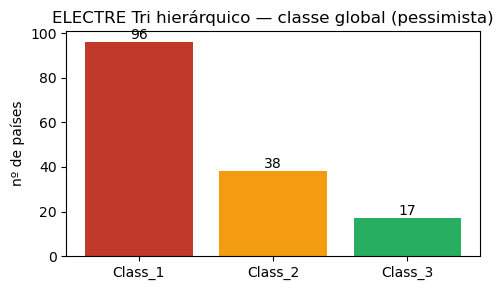


Classe global por país (Freedom_and_Prosperity):
Angola                              Class_1
Albania                             Class_2
United Arab Emirates                Class_1
Argentina                           Class_2
Armenia                             Class_2
Australia                           Class_3
Austria                             Class_2
Azerbaijan                          Class_1
Burundi                             Class_1
Belgium                             Class_3
Benin                               Class_1
Burkina Faso                        Class_1
Bangladesh                          Class_1
Bulgaria                            Class_2
Bahrain                             Class_1
Bosnia and Herzegovina              Class_1
Belarus                             Class_1
Bolivia                             Class_1
Brazil                              Class_2
Barbados                            Class_2
Bhutan                              Class_1
Botswana                  

In [9]:
contagem = res_pess["Freedom_and_Prosperity"].value_counts().reindex(categories, fill_value=0)
print("Distribuição na classe global (Freedom_and_Prosperity):")
print(contagem)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(contagem.index, contagem.values, color=["#c0392b", "#f39c12", "#27ae60"])
ax.set_ylabel("nº de países")
ax.set_title("ELECTRE Tri hierárquico — classe global (pessimista)")
for x, y in zip(contagem.index, contagem.values):
    ax.text(x, y, str(y), ha="center", va="bottom")
plt.tight_layout()
plt.show()

# Melhores e piores segundo a classe global
print("\nClasse global por país (Freedom_and_Prosperity):")
print(res_pess["Freedom_and_Prosperity"].to_string())

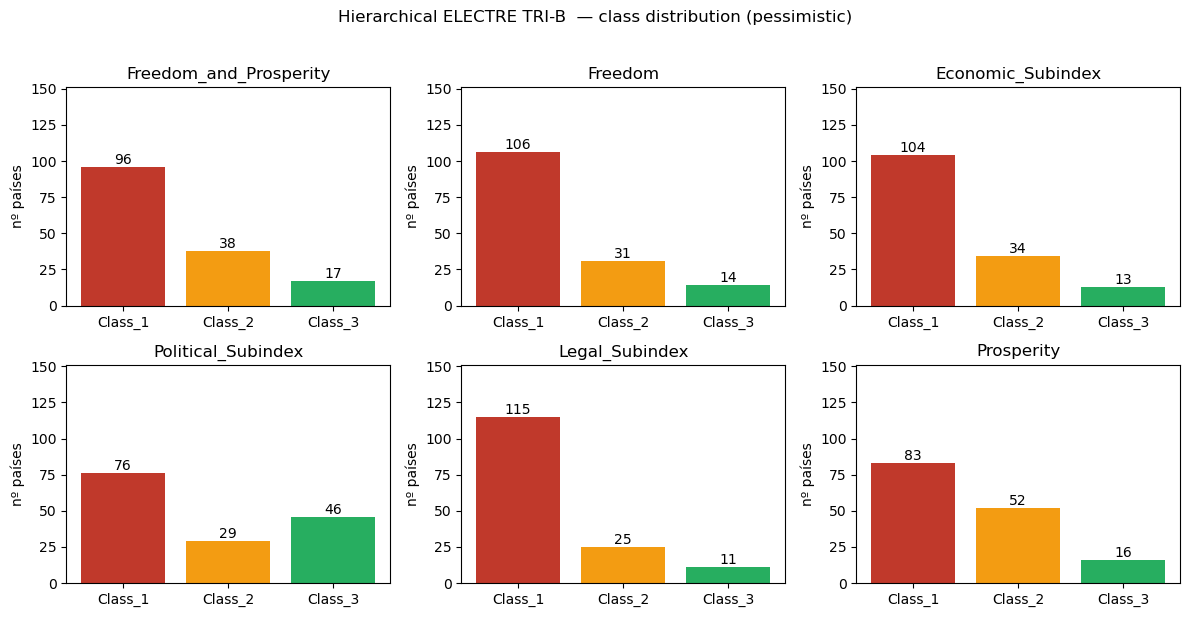

In [10]:
nos = list(lambdas.keys())  # raiz + dimensões + subdimensões
cores = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#27ae60"}

ncols = 3
nrows = math.ceil(len(nos) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, no in zip(axes, nos):
    contagem = res_pess[no].value_counts().reindex(categories, fill_value=0)
    ax.bar(contagem.index, contagem.values, color=[cores[c] for c in contagem.index])
    ax.set_title(no)
    ax.set_ylabel("nº países")
    ax.set_ylim(0, len(df))
    for x, y in zip(contagem.index, contagem.values):
        ax.text(x, y, str(y), ha="center", va="bottom")

# desliga os subplots que sobraram
for ax in axes[len(nos):]:
    ax.axis("off")

fig.suptitle("Hierarchical ELECTRE TRI-B  — class distribution (pessimistic)",
             y=1.02)
plt.tight_layout()
plt.show()

In [11]:
def country_hierarchy(country, results=res_pess, show=True):
    if country not in results.index:
        raise KeyError(f"Country '{country}' not found. "
                       f"e.g.: {list(results.index[:5])} ...")
    values = df.loc[country]
    rows = []
    def visit(node, level):
        if node.is_leaf():
            cls, value = "", float(values[node.leaf_id])
        else:
            cls, value = results.loc[country, node.name], None
        rows.append({"Level": level, "Criterion": node.name,
                     "Class": cls, "Value": value})
        for child in node.children:
            visit(child, level + 1)
    visit(Raiz, 0)
    table = pd.DataFrame(rows)
    if show:
        print(f"Country: {country}\n" + "=" * 62)
        for _, r in table.iterrows():
            label = "  " * r["Level"] + r["Criterion"]
            if r["Class"]:
                print(f"{label:<55s} -> {r['Class']}")
            else:
                print(f"{label:<55s}    (value = {r['Value']:.2f})")
    return table


_=country_hierarchy("Brazil")

Country: Brazil
Freedom_and_Prosperity                                  -> Class_2
  Freedom                                               -> Class_1
    Economic_Subindex                                   -> Class_1
      Proper_Rights                                        (value = 61.94)
      Trade_Freedom                                        (value = 79.28)
      Investm_Freedom                                      (value = 40.00)
      Womens_Economic_Freedom                              (value = 85.00)
    Political_Subindex                                  -> Class_3
      PF_Elections                                         (value = 94.83)
      Civil_Liberties                                      (value = 80.95)
      Political_Rights                                     (value = 91.00)
      Legislative_Constraints_on_the_Executive             (value = 93.60)
    Legal_Subindex                                      -> Class_1
      Clarity_of_the_Law                         

# Simulation

In [12]:
N_SIM = 10          # número de iterações de Monte Carlo
SEED = 42             # reprodutibilidade
categories = ["Class_1", "Class_2", "Class_3"]  # Class_3 is the best

rng = np.random.default_rng(SEED)

nodes = list(lambdas.keys())
alt_dicts = {name: df.loc[name].to_dict() for name in df.index}

# counts[país][nó] -> Counter({classe: nº de vezes})
counts = {c: {n: Counter() for n in nodes} for c in df.index}

for _ in range(N_SIM):
    model.q = {lf: rng.uniform(3, 5) for lf in leaves}
    model.p = {lf: rng.uniform(5, 7) for lf in leaves}
    model.v = {lf: rng.uniform(30, 50) for lf in leaves}
    model.profiles = {
        "b1": {lf: rng.uniform(60, 70) for lf in leaves},
        "b2": {lf: rng.uniform(80, 90) for lf in leaves},
    }
    for name, alt in alt_dicts.items():
        assigned = model.assign_all_nodes(alt, procedure="pessimistic")
        for n in nodes:
            counts[name][n][assigned[n]] += 1

# restaura os parâmetros do cenário-base no modelo
model.q, model.p, model.v, model.profiles = q, p, v, profiles

print(f"Simulação concluída: {N_SIM} iterações x {len(df)} países x {len(nodes)} nós.")

Simulação concluída: 10 iterações x 151 países x 6 nós.


In [13]:
cat_index = {c: i for i, c in enumerate(categories)} 

def best_worst_mode(counter):
    observados = [c for c in categories if counter[c] > 0]
    best = max(observados, key=cat_index.get)   # classe mais alta observada
    worst = min(observados, key=cat_index.get)  # classe mais baixa observada
    most_frequent = max(categories, key=lambda c: (counter[c], cat_index[c]))
    return best, worst, most_frequent

registros = {}
for name in df.index:
    linha = {}
    for n in nodes:
        b, w, m = best_worst_mode(counts[name][n])
        linha[(n, "best")] = b
        linha[(n, "worst")] = w
        linha[(n, "most_frequent")] = m
    registros[name] = linha

smaa_table = pd.DataFrame(registros).T
smaa_table.columns = pd.MultiIndex.from_tuples(smaa_table.columns, names=["node", "stat"])


smaa_table = smaa_table[[(n, s) for n in nodes for s in ("best", "worst", "most_frequent")]]
smaa_table

node                 Freedom_and_Prosperity                         Freedom  \
stat                                   best    worst most_frequent     best   
Angola                              Class_1  Class_1       Class_1  Class_1   
Albania                             Class_2  Class_1       Class_2  Class_2   
United Arab Emirates                Class_1  Class_1       Class_1  Class_1   
Argentina                           Class_2  Class_1       Class_2  Class_1   
Armenia                             Class_2  Class_1       Class_2  Class_1   
...                                     ...      ...           ...      ...   
Vietnam                             Class_1  Class_1       Class_1  Class_1   
Yemen                               Class_1  Class_1       Class_1  Class_1   
South Africa                        Class_1  Class_1       Class_1  Class_1   
Zambia                              Class_1  Class_1       Class_1  Class_1   
Zimbabwe                            Class_1  Class_1       Class_1  Class_1   

node                                        Economic_Subindex           \
stat                    worst most_frequent              best    worst   
Angola                Class_1       Class_1           Class_1  Class_1   
Albania               Class_1       Class_1           Class_1  Class_1   
United Arab Emirates  Class_1       Class_1           Class_1  Class_1   
Argentina             Class_1       Class_1           Class_1  Class_1   
Armenia               Class_1       Class_1           Class_2  Class_1   
...                       ...           ...               ...      ...   
Vietnam               Class_1       Class_1           Class_2  Class_1   
Yemen                 Class_1       Class_1           Class_1  Class_1   
South Africa          Class_1       Class_1           Class_1  Class_1   
Zambia                Class_1       Class_1           Class_1  Class_1   
Zimbabwe              Class_1       Class_1           Class_1  Class_1   

node                               Political_Subindex                         \
stat                 most_frequent               best    worst most_frequent   
Angola                     Class_1            Class_1  Class_1       Class_1   
Albania                    Class_1            Class_2  Class_2       Class_2   
United Arab Emirates       Class_1            Class_1  Class_1       Class_1   
Argentina                  Class_1            Class_3  Class_2       Class_3   
Armenia                    Class_2            Class_2  Class_2       Class_2   
...                            ...                ...      ...           ...   
Vietnam                    Class_1            Class_1  Class_1       Class_1   
Yemen                      Class_1            Class_1  Class_1       Class_1   
South Africa               Class_1            Class_3  Class_3       Class_3   
Zambia                     Class_1            Class_2  Class_2       Class_2   
Zimbabwe                   Class_1            Class_1  Class_1       Class_1   

node                 Legal_Subindex                        Prosperity  \
stat                           best    worst most_frequent       best   
Angola                      Class_1  Class_1       Class_1    Class_1   
Albania                     Class_1  Class_1       Class_1    Class_2   
United Arab Emirates        Class_1  Class_1       Class_1    Class_2   
Argentina                   Class_1  Class_1       Class_1    Class_2   
Armenia                     Class_1  Class_1       Class_1    Class_2   
...                             ...      ...           ...        ...   
Vietnam                     Class_1  Class_1       Class_1    Class_2   
Yemen                       Class_1  Class_1       Class_1    Class_1   
South Africa                Class_1  Class_1       Class_1    Class_1   
Zambia                      Class_1  Class_1       Class_1    Class_1   
Zimbabwe                    Class_1  Class_1       Class_1    Class_1   

node              

## Índices de aceitabilidade de classe (saída clássica do SMAA-TRI)

In [14]:
# --- Índices de aceitabilidade de classe (saída clássica do SMAA-TRI) --------

# Para cada país e cada nó, a fração das iterações em que o país foi atribuído
# a cada classe -> probabilidade (empírica) de pertencer àquela classe.

accept = {}
for name in df.index:
    linha = {}
    for n in nodes:
        total = sum(counts[name][n].values())  # == N_SIM
        for c in categories:
            linha[(n, c)] = counts[name][n][c] / total
    accept[name] = linha

acceptability = pd.DataFrame(accept).T
acceptability.columns = pd.MultiIndex.from_tuples(acceptability.columns, names=["node", "class"])
acceptability = acceptability[[(n, c) for n in nodes for c in categories]]


def class_acceptability(node="Freedom_and_Prosperity"):
    tab = acceptability[node].copy()
    return tab.sort_values(list(categories[::-1]), ascending=False)

class_acceptability("Freedom_and_Prosperity").round(3)

class,Class_1,Class_2,Class_3
Belgium,0.0,0.0,1.0
Switzerland,0.0,0.0,1.0
Denmark,0.0,0.0,1.0
Finland,0.0,0.0,1.0
Ireland,0.0,0.0,1.0
...,...,...,...
Vietnam,1.0,0.0,0.0
Yemen,1.0,0.0,0.0
South Africa,1.0,0.0,0.0
Zambia,1.0,0.0,0.0


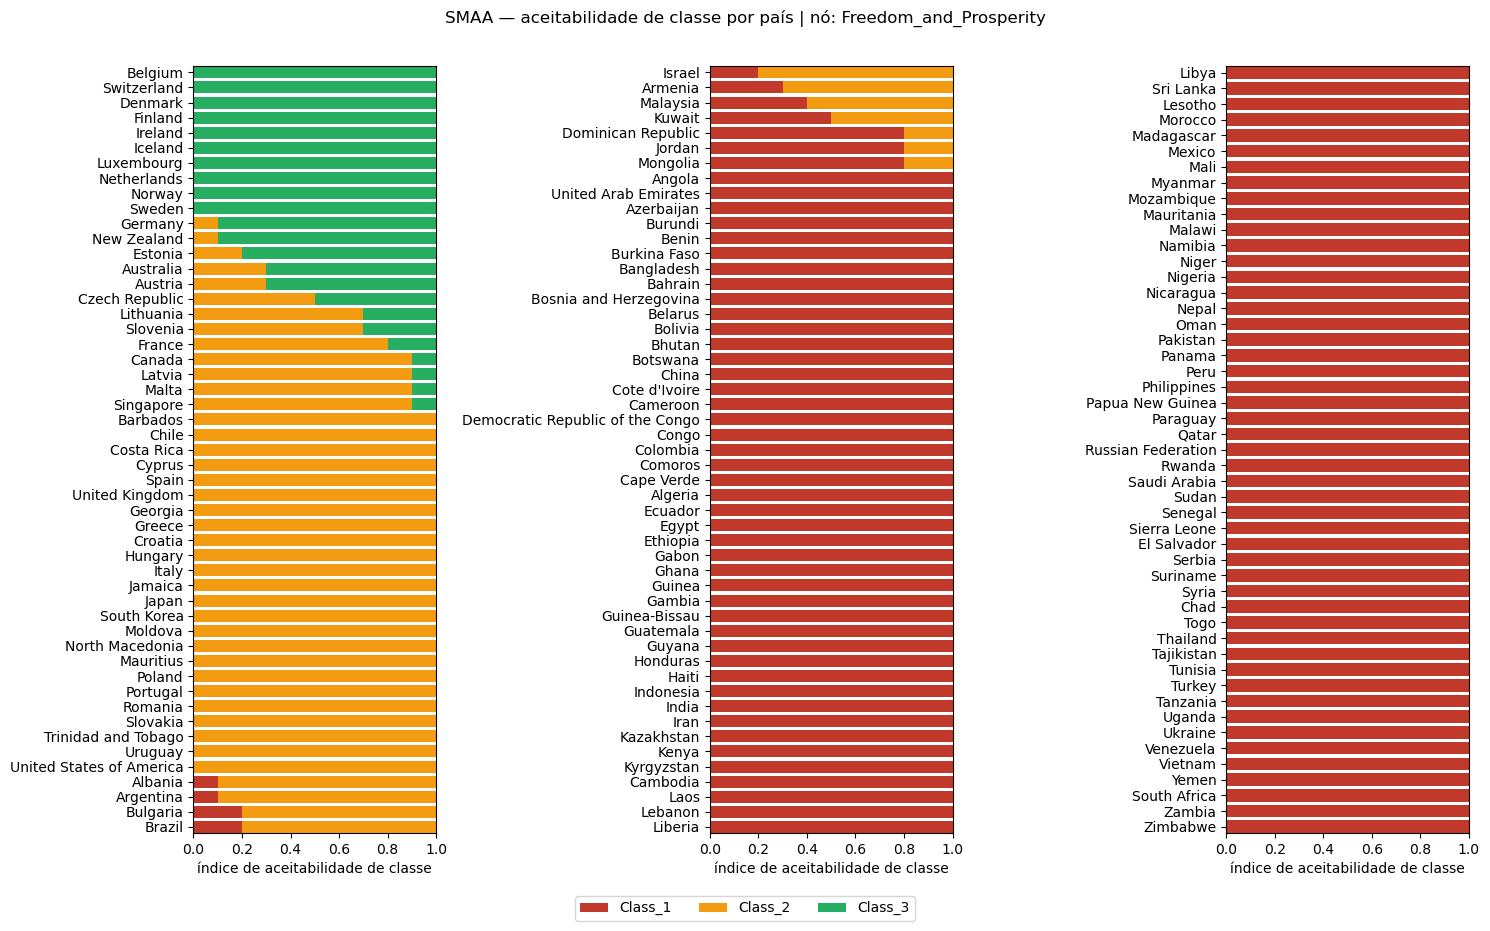

In [15]:
cores = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#27ae60"}

def plot_acceptability(node="Freedom_and_Prosperity", ncols=3):
    """Aceitabilidade de classe por país, distribuída em `ncols` painéis
    lado a lado para não ficar excessivamente longa em coluna única."""
    tab = acceptability[node].copy()
    # ordena dos "melhores" (maior prob. de Class_3) aos "piores"
    tab = tab.sort_values(list(categories[::-1]), ascending=False)

    # divide o ranking em blocos contíguos, um por painel
    chunk = math.ceil(len(tab) / ncols)
    blocos = [tab.iloc[i:i + chunk] for i in range(0, len(tab), chunk)]

    fig, axes = plt.subplots(
        1, len(blocos),
        figsize=(5 * len(blocos), max(3, 0.18 * chunk)),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, bloco in zip(axes, blocos):
        esquerda = pd.Series(0.0, index=bloco.index)
        for c in categories:
            ax.barh(bloco.index, bloco[c], left=esquerda, color=cores[c], label=c)
            esquerda += bloco[c]
        ax.set_xlim(0, 1)
        ax.set_xlabel("índice de aceitabilidade de classe")
        ax.invert_yaxis()  # melhores no topo de cada painel
        ax.margins(y=0)

    # legenda e título únicos para a figura
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center",
               ncol=len(categories), bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f"SMAA — aceitabilidade de classe por país | nó: {node}")
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    plt.show()

plot_acceptability("Freedom_and_Prosperity")

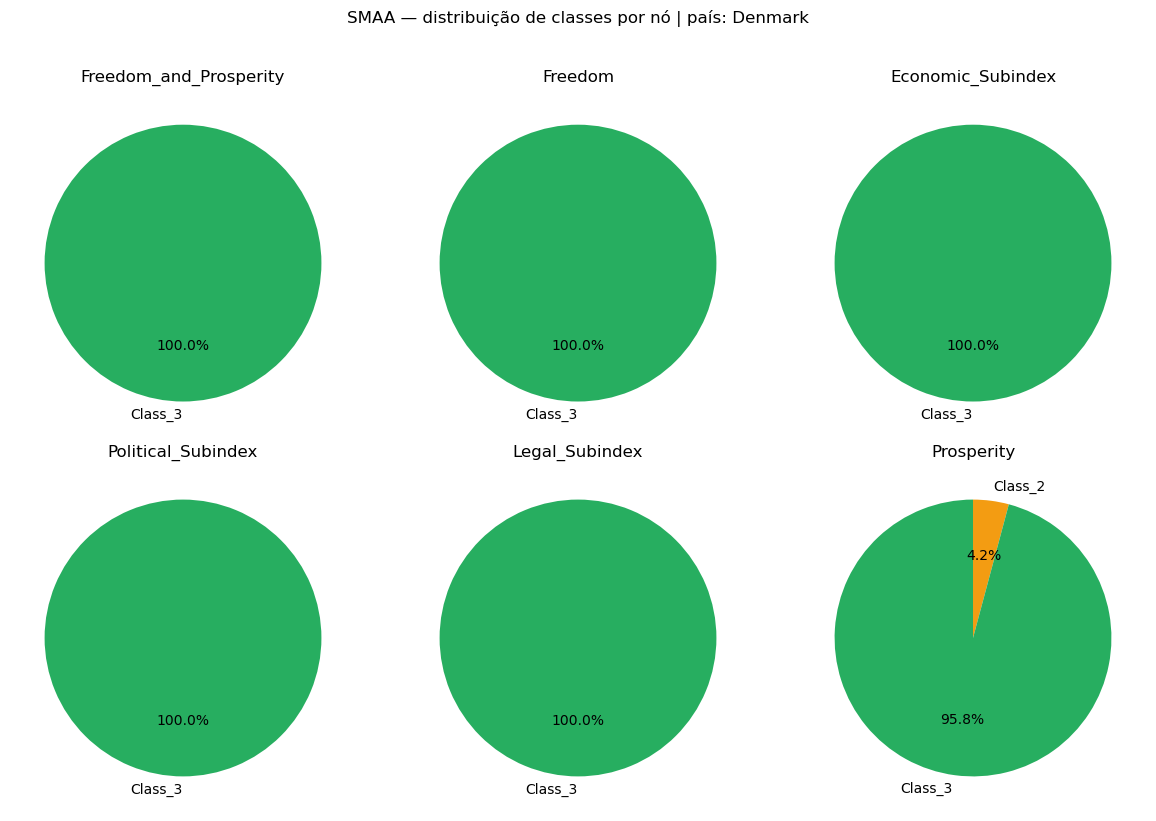

In [40]:
# --- Gráficos de pizza por nó para um país ----------------------------------
def plot_country_pies(country, ncols=3):
    """Para um país, desenha um gráfico de pizza por nó da hierarquia com a
    porcentagem de iterações em que ele caiu em cada classe (aceitabilidades)."""
    if country not in acceptability.index:
        raise KeyError(f"Country '{country}' not found. "
                       f"e.g.: {list(acceptability.index[:5])} ...")

    nrows = math.ceil(len(nodes) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten()

    for ax, n in zip(axes, nodes):
        probs = acceptability.loc[country, n].reindex(categories)
        presentes = probs[probs > 0]  # omite classes com 0%
        ax.pie(presentes.values,
               labels=presentes.index,
               colors=[cores[c] for c in presentes.index],
               autopct=lambda pct: f"{pct:.1f}%",
               startangle=90,
               counterclock=False)
        ax.set_title(n)

    # desliga os subplots que sobraram
    for ax in axes[len(nodes):]:
        ax.axis("off")

    fig.suptitle(f"SMAA — distribuição de classes por nó | país: {country}", y=1.02)
    plt.tight_layout()
    plt.show()


plot_country_pies("Denmark")